# 两层神经网络完整实现

> **斯坦福 CS231n Assignment 1 Q3+Q5** | Two-Layer Neural Network

## 本章导读

本节从零实现一个完整的两层神经网络。我们将经历从直觉到手算、从代码到实验的完整路径，理解参数化模型、前向传播、反向传播和训练循环的每一个细节。

**学习目标：**
- 理解参数化模型 $f(x) = W_2 \text{ReLU}(W_1 x + b_1) + b_2$ 的结构
- 手算前向传播和反向传播
- 从零实现 TwoLayerNet 类（前向、损失、反向、训练）
- 调节超参数（隐藏层大小、学习率、正则化）
- 可视化损失曲线和决策边界

**参考来源：** [CS231n Assignment 1](https://cs231n.github.io/assignments2021/assignment1/) | [Neural Nets Notes](https://cs231n.github.io/neural-networks-1/)

## 1. 直觉理解：参数化模型

### 从 k-NN 到参数化模型

k-NN 的问题在于「预测时才计算」，没有从训练数据中提取模式。参数化模型的核心思想是：**用一组参数 $W, b$ 压缩训练数据的模式**，预测时只需 $f(x) = Wx + b$。

### 两层神经网络的结构

$$f(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

- **第一层**（隐藏层）：$z_1 = W_1 x + b_1$，然后 $a_1 = \text{ReLU}(z_1)$
- **第二层**（输出层）：$s = W_2 a_1 + b_2$（分类得分）
- **ReLU 激活**：$\text{ReLU}(z) = \max(0, z)$，引入非线性

### 为什么需要两层？

单层线性分类器只能学习线性决策边界。加入隐藏层和 ReLU 后，网络可以拟合任意非线性决策边界——这是**通用近似定理**的基础。

### 前向传播的数据流

```
输入 x (D维)
  ↓  W1 (D×H), b1 (H维)
线性变换 z1 = W1·x + b1
  ↓  ReLU
激活 a1 = ReLU(z1)
  ↓  W2 (H×C), b2 (C维)
得分 s = W2·a1 + b2
  ↓  Softmax
概率 p = softmax(s)
  ↓  交叉熵
损失 L = -log(p[正确类别])
```

### 反向传播的梯度流

反向传播沿计算图反向传递梯度：
1. 从损失开始：$\frac{\partial L}{\partial s}$
2. 通过 softmax：$\frac{\partial L}{\partial s} = p - \text{one\_hot}(y)$
3. 回到隐藏层：$\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial s} \cdot W_2^T$
4. 通过 ReLU：$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \cdot \mathbb{1}[z_1 > 0]$
5. 到权重：$\frac{\partial L}{\partial W_1} = x^T \cdot \frac{\partial L}{\partial z_1}$

## 2. 手算验证：前向传播

### 2D 玩具数据手算

设输入 $x = [1, 2]^T$，3 个类别，隐藏层 2 维。

**权重初始化：**
$$W_1 = \begin{bmatrix} 0.1 & 0.2 \\ 0.3 & 0.4 \end{bmatrix}, \quad b_1 = [0.0, 0.1]^T$$
$$W_2 = \begin{bmatrix} 0.5 & 0.6 \\ 0.7 & 0.8 \\ 0.9 & 1.0 \end{bmatrix}, \quad b_2 = [0.0, 0.0, 0.0]^T$$

**前向传播：**

1. $z_1 = W_1 x + b_1 = [0.1 \times 1 + 0.2 \times 2 + 0.0, \; 0.3 \times 1 + 0.4 \times 2 + 0.1] = [0.5, 1.2]$

2. $a_1 = \text{ReLU}(z_1) = [\max(0, 0.5), \max(0, 1.2)] = [0.5, 1.2]$

3. $s = W_2 a_1 + b_2 = [0.5 \times 0.5 + 0.6 \times 1.2, \; 0.7 \times 0.5 + 0.8 \times 1.2, \; 0.9 \times 0.5 + 1.0 \times 1.2]$
   $= [0.97, 1.31, 1.65]$

### 手算 Softmax 损失

得分 $s = [0.97, 1.31, 1.65]$，假设正确标签 $y = 0$。

1. 数值稳定化：$s_{max} = 1.65$，$s' = s - 1.65 = [-0.68, -0.34, 0.0]$
2. 指数化：$e^{s'} = [0.5066, 0.7118, 1.0]$
3. 归一化：$Z = 2.2184$，$p = [0.2283, 0.3209, 0.4508]$
4. 交叉熵损失：$L = -\log(p_0) = -\log(0.2283) \approx 1.477$

### 手算反向传播

1. $\frac{\partial L}{\partial s} = p - \text{one\_hot}(y) = [0.2283 - 1, 0.3209, 0.4508] = [-0.7717, 0.3209, 0.4508]$

2. $\frac{\partial L}{\partial W_2}$：$\frac{\partial L}{\partial s}^T \cdot a_1$（外积）
   - 第一行：$[-0.7717 \times 0.5, -0.7717 \times 1.2] = [-0.3859, -0.9260]$
   - 第二行：$[0.3209 \times 0.5, 0.3209 \times 1.2] = [0.1604, 0.3851]$
   - 第三行：$[0.4508 \times 0.5, 0.4508 \times 1.2] = [0.2254, 0.5410]$

3. $\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial s} \cdot W_2$
   - $a_{1,1}$：$-0.7717 \times 0.5 + 0.3209 \times 0.7 + 0.4508 \times 0.9 = 0.0412$
   - $a_{1,2}$：$-0.7717 \times 0.6 + 0.3209 \times 0.8 + 0.4508 \times 1.0 = 0.0606$

4. $\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \cdot \mathbb{1}[z_1 > 0] = [0.0412, 0.0606]$（ReLU 梯度，$z_1$ 全为正）

5. $\frac{\partial L}{\partial W_1} = x^T \cdot \frac{\partial L}{\partial z_1}$
   - 第一行：$[1 \times 0.0412, 1 \times 0.0606] = [0.0412, 0.0606]$
   - 第二行：$[2 \times 0.0412, 2 \times 0.0606] = [0.0824, 0.1212]$

In [6]:
# 代码实现：验证手算结果
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 手算验证
x = np.array([1.0, 2.0])
y = 0  # correct label

W1 = np.array([[0.1, 0.2], [0.3, 0.4]])
b1 = np.array([0.0, 0.1])
W2 = np.array([[0.5, 0.6], [0.7, 0.8], [0.9, 1.0]])
b2 = np.array([0.0, 0.0, 0.0])

# Forward pass
z1 = W1.T @ x + b1
a1 = np.maximum(0, z1)
s = W2 @ a1 + b2
print(f"z1 = {z1}")           # [0.5, 1.2]
print(f"a1 = {a1}")           # [0.5, 1.2]
print(f"scores = {s}")         # [0.97, 1.31, 1.65]

# Softmax loss
shifted = s - np.max(s)
exp_s = np.exp(shifted)
probs = exp_s / np.sum(exp_s)
loss = -np.log(probs[y])
print(f"probs = {probs}")
print(f"loss = {loss:.4f}")    # ~1.477

# Backward pass
dscores = probs.copy()
dscores[y] -= 1
print(f"dscores = {dscores}")  # [-0.7717, 0.3209, 0.4508]

dW2 = np.outer(dscores, a1)
print(f"dW2 = \n{dW2}")

da1 = W2.T @ dscores
print(f"da1 = {da1}")

dz1 = da1 * (z1 > 0)
print(f"dz1 = {dz1}")

dW1 = np.outer(x, dz1)
print(f"dW1 = \n{dW1}")

z1 = [0.7 1.1]
a1 = [0.7 1.1]
scores = [1.01 1.37 1.73]
probs = [0.22282818 0.31938619 0.45778562]
loss = 1.5014
dscores = [-0.77717182  0.31938619  0.45778562]
dW2 = 
[[-0.54402027 -0.854889  ]
 [ 0.22357033  0.35132481]
 [ 0.32044994  0.50356419]]
da1 = [0.24699149 0.24699149]
dz1 = [0.24699149 0.24699149]
dW1 = 
[[0.24699149 0.24699149]
 [0.49398298 0.49398298]]


## 3. 代码实现：TwoLayerNet 类

现在实现完整的两层神经网络类。这个类包含：
- `__init__`：初始化权重（He 初始化）
- `forward`：前向传播，返回得分和缓存
- `loss`：计算损失和梯度
- `train`：SGD 训练循环
- `predict`：预测

### 权重初始化：He 初始化

对于 ReLU 激活，推荐使用 He 初始化：
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{D_{in}}}\right)$$

这确保前向传播时方差不爆炸或消失。

In [8]:
class TwoLayerNet:
    """Two-layer neural network with ReLU and Softmax.
    
    Architecture: input -> FC -> ReLU -> FC -> Softmax
    """
    def __init__(self, input_dim, hidden_dim, num_classes, reg=0.0):
        # He initialization for ReLU
        self.params = {
            'W1': np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(hidden_dim),
            'W2': np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim),
            'b2': np.zeros(num_classes),
        }
        self.reg = reg
    
    def forward(self, X):
        """Forward pass. Returns scores and cache."""
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        z1 = X @ W1 + b1          # (N, H)
        a1 = np.maximum(0, z1)    # (N, H) ReLU
        scores = a1 @ W2 + b2     # (N, C)
        cache = (X, W1, b1, z1, a1, W2, b2)
        return scores, cache
    
    def loss(self, X, y):
        """Compute softmax loss and gradients."""
        scores, cache = self.forward(X)
        N = X.shape[0]
        # Numerical stability: shift by max
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        # Cross-entropy loss
        correct_logprobs = -np.log(probs[np.arange(N), y])
        data_loss = np.sum(correct_logprobs) / N
        reg_loss = 0.5 * self.reg * (np.sum(self.params['W1']**2) + np.sum(self.params['W2']**2))
        loss = data_loss + reg_loss
        
        # Backward pass
        X, W1, b1, z1, a1, W2, b2 = cache
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        
        dW2 = a1.T @ dscores + self.reg * W2
        db2 = np.sum(dscores, axis=0)
        da1 = dscores @ W2.T
        dz1 = da1 * (z1 > 0)  # ReLU gradient
        dW1 = X.T @ dz1 + self.reg * W1
        db1 = np.sum(dz1, axis=0)
        
        grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
        return loss, grads
    
    def train(self, X, y, lr=1e-2, num_iters=1000, batch_size=None, verbose=False):
        """Train with SGD."""
        N = X.shape[0]
        if batch_size is None:
            batch_size = N
        losses = []
        for it in range(num_iters):
            batch_idx = np.random.choice(N, batch_size, replace=True) if batch_size < N else np.arange(N)
            X_batch, y_batch = X[batch_idx], y[batch_idx]
            loss, grads = self.loss(X_batch, y_batch)
            for k in self.params:
                self.params[k] -= lr * grads[k]
            if verbose and it % 100 == 0:
                print(f"  iter {it}: loss = {loss:.4f}")
            losses.append(loss)
        return losses
    
    def predict(self, X):
        scores, _ = self.forward(X)
        return np.argmax(scores, axis=1)

print("TwoLayerNet class defined successfully")

TwoLayerNet class defined successfully


## 4. 生成 2D 玩具数据

为了可视化决策边界，我们生成螺旋形 2D 数据。螺旋数据是非线性可分的经典基准——线性分类器无法处理，但两层神经网络可以。

Data shape: X=(300, 2), y=(300,)
Classes: [0 1 2]
Visualization 1: Spiral toy data


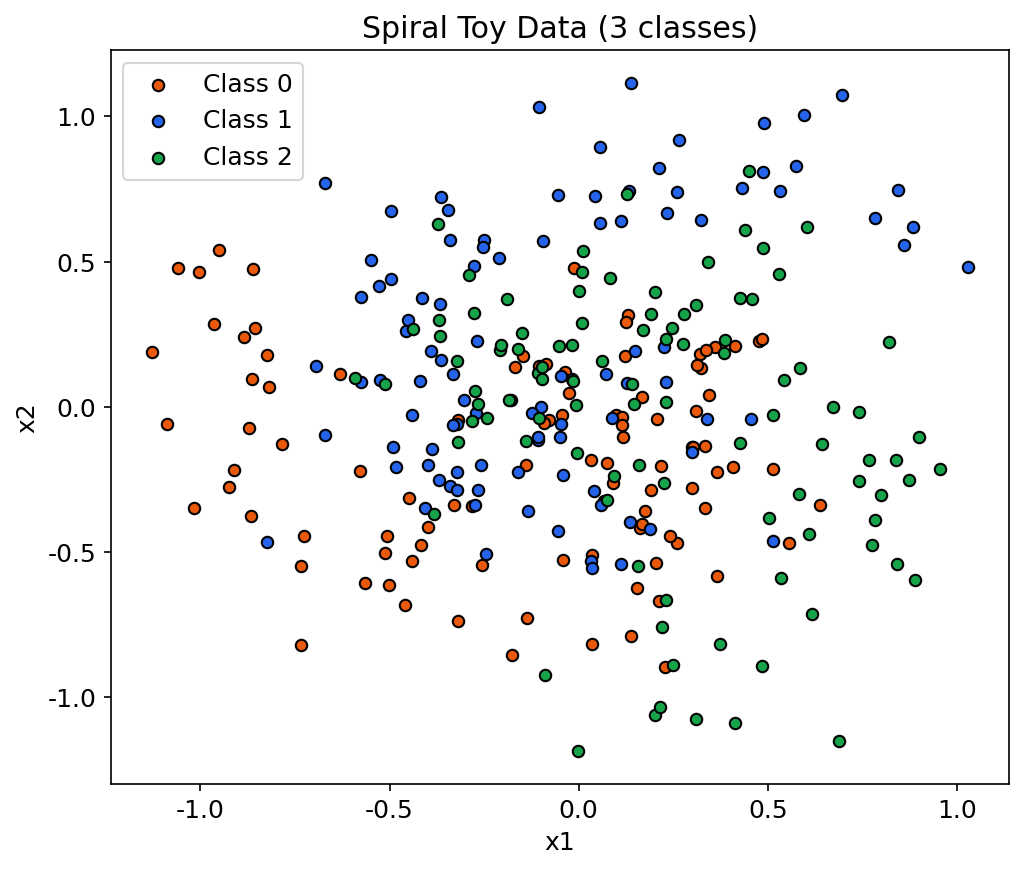

In [10]:
def generate_spiral_data(n_per_class=100, n_classes=3, noise=0.2):
    """Generate spiral 2D toy data for classification."""
    X = np.zeros((n_per_class * n_classes, 2))
    y = np.zeros(n_per_class * n_classes, dtype=int)
    for c in range(n_classes):
        idx = range(n_per_class * c, n_per_class * (c + 1))
        radius = np.linspace(0.0, 1.0, n_per_class)
        theta = np.linspace(c * 2 * np.pi / n_classes, 
                           (c + 2.5) * 2 * np.pi / n_classes, n_per_class)
        X[idx] = np.c_[radius * np.sin(theta), radius * np.cos(theta)] + \
                 np.random.randn(n_per_class, 2) * noise
        y[idx] = c
    return X, y

np.random.seed(42)
X_spiral, y_spiral = generate_spiral_data(n_per_class=100, n_classes=3)
print(f"Data shape: X={X_spiral.shape}, y={y_spiral.shape}")
print(f"Classes: {np.unique(y_spiral)}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#ea580c', '#2563eb', '#16a34a']
for c in range(3):
    mask = y_spiral == c
    ax.scatter(X_spiral[mask, 0], X_spiral[mask, 1], c=colors[c], 
              edgecolors='k', s=30, label=f'Class {c}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Spiral Toy Data (3 classes)')
ax.legend()
plt.tight_layout()
plt.savefig('spiral_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Spiral toy data")

## 5. 训练循环

使用 SGD（随机梯度下降）训练网络。关键超参数：
- **学习率** `lr`：控制步长大小
- **迭代次数** `num_iters`：训练步数
- **正则化** `reg`：L2 正则化强度
- **隐藏层大小** `hidden_dim`：控制模型容量

In [12]:
# Train TwoLayerNet on spiral data
np.random.seed(42)
net = TwoLayerNet(input_dim=2, hidden_dim=50, num_classes=3, reg=1e-3)
losses = net.train(X_spiral, y_spiral, lr=0.5, num_iters=1500, verbose=True)

# Evaluate
train_acc = np.mean(net.predict(X_spiral) == y_spiral)
print(f"\nTraining accuracy: {train_acc:.2%}")
print(f"Final loss: {losses[-1]:.4f}")

  iter 0: loss = 1.2960
  iter 100: loss = 0.8456
  iter 200: loss = 0.7875
  iter 300: loss = 0.7696
  iter 400: loss = 0.7617
  iter 500: loss = 0.7571
  iter 600: loss = 0.7537
  iter 700: loss = 0.7512
  iter 800: loss = 0.7493
  iter 900: loss = 0.7477
  iter 1000: loss = 0.7465
  iter 1100: loss = 0.7454
  iter 1200: loss = 0.7445
  iter 1300: loss = 0.7437
  iter 1400: loss = 0.7430

Training accuracy: 71.67%
Final loss: 0.7424


Visualization 2: Training loss curve


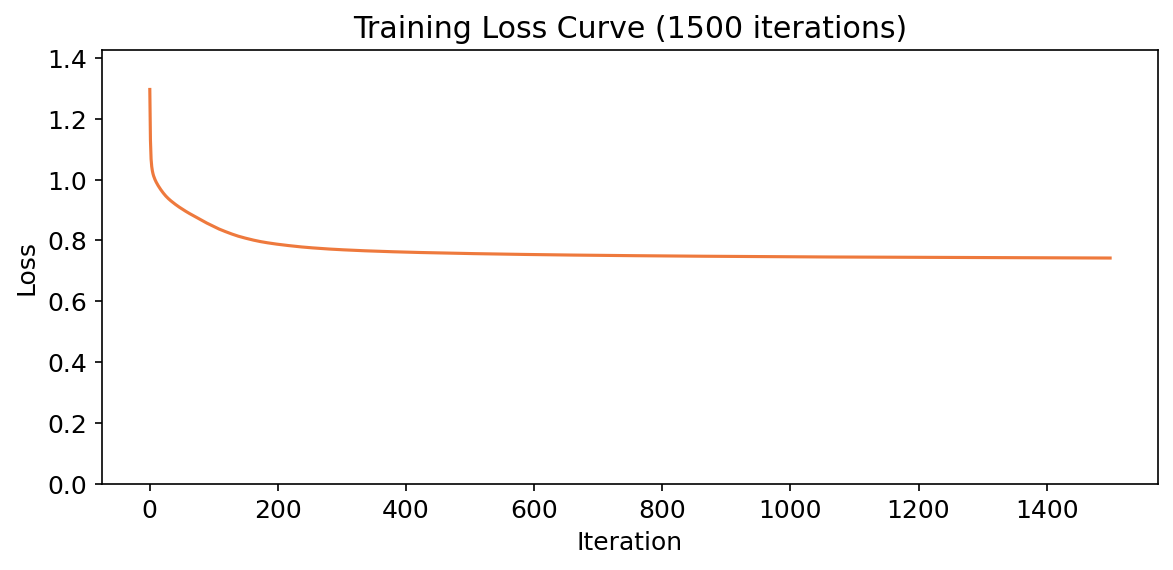

In [13]:
# Visualize loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Curve (1500 iterations)')
ax.set_ylim(0, max(losses) * 1.1)
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Training loss curve")

Visualization 3: Decision boundary


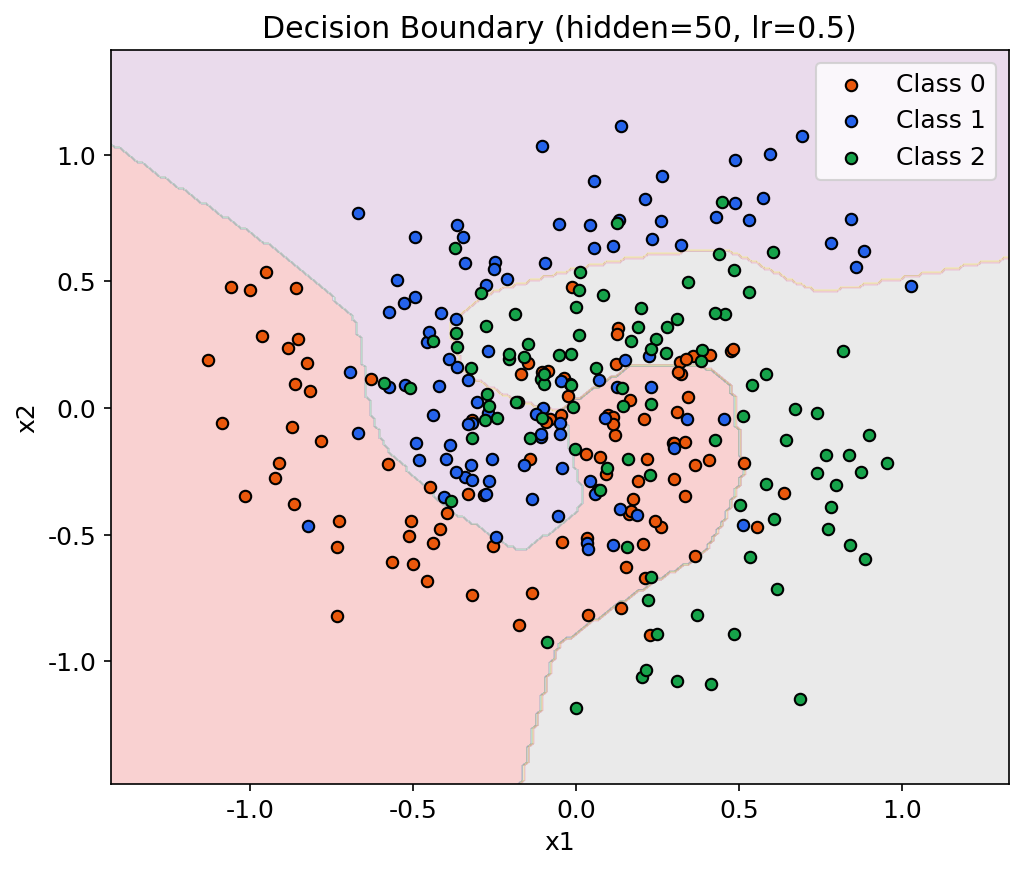

In [14]:
# Visualize decision boundary
def plot_decision_boundary(net, X, y, title='Decision Boundary'):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = net.predict(grid).reshape(xx.shape)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='Set1')
    for c in range(3):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[c], 
                  edgecolors='k', s=30, label=f'Class {c}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_decision_boundary(net, X_spiral, y_spiral, 'Decision Boundary (hidden=50, lr=0.5)')
print("Visualization 3: Decision boundary")

## 6. 实验观察：超参数调节

### 6.1 隐藏层大小的影响

隐藏层大小控制模型容量：
- 太小（如 5）：欠拟合，无法表达螺旋边界
- 适中（如 50）：良好拟合
- 太大（如 200）：可能过拟合

hidden=  5: accuracy=67.00%, final_loss=0.7685
hidden= 10: accuracy=71.67%, final_loss=0.7509
hidden= 25: accuracy=70.33%, final_loss=0.7351
hidden= 50: accuracy=72.33%, final_loss=0.7393
hidden=100: accuracy=71.33%, final_loss=0.7427
hidden=200: accuracy=71.33%, final_loss=0.7548
Visualization 4: Hidden layer size comparison


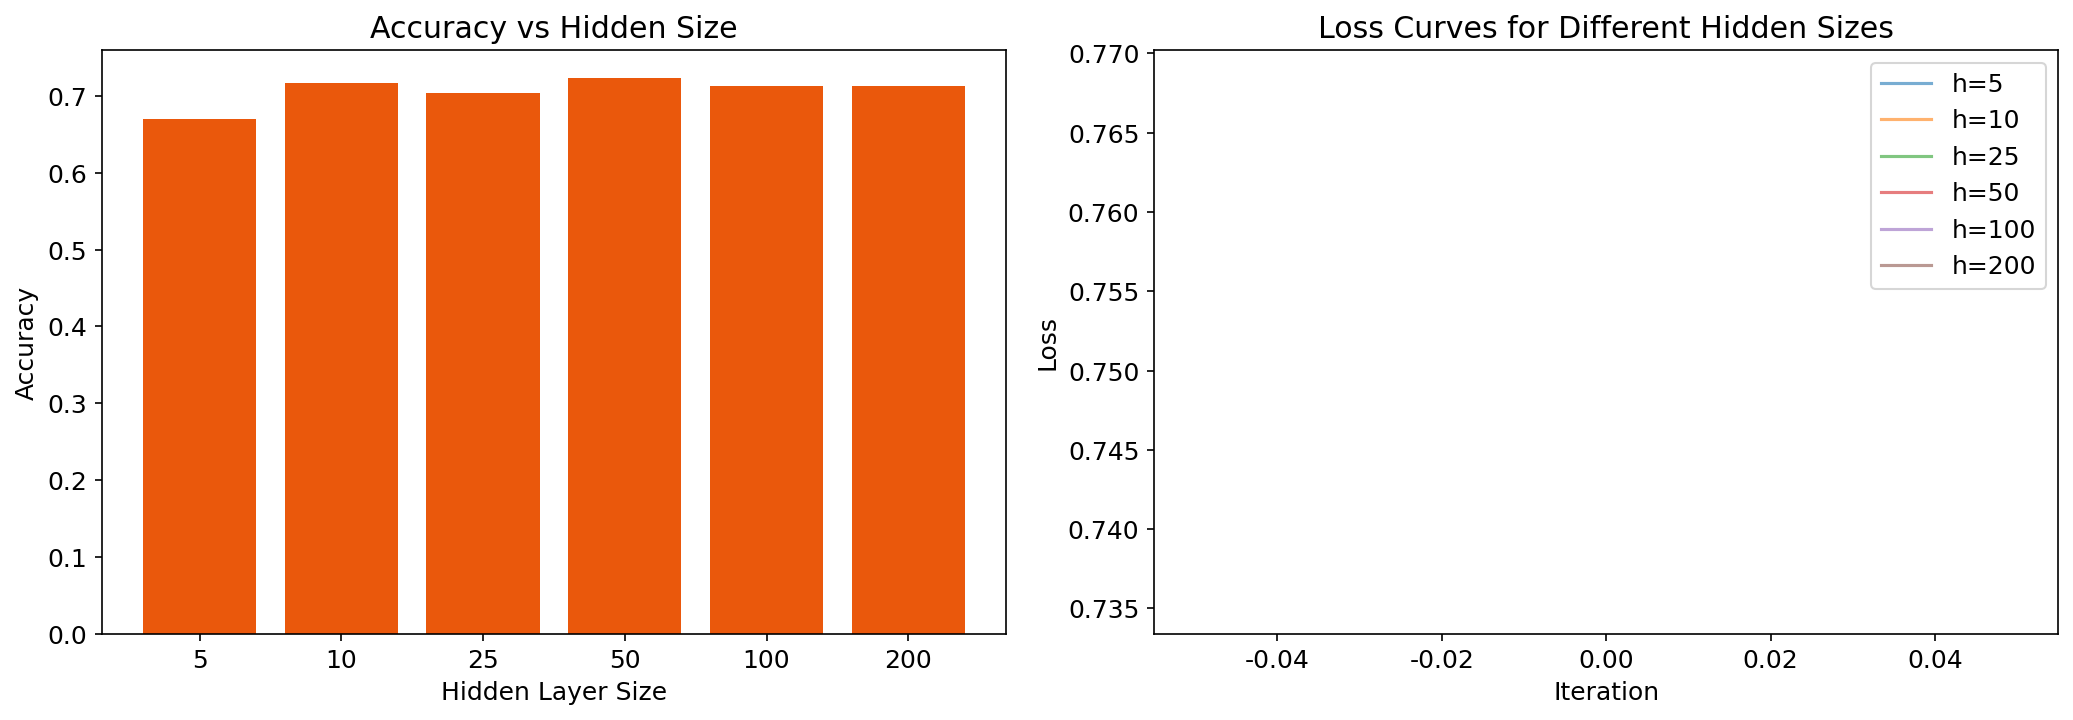

In [16]:
# Experiment: effect of hidden layer size
np.random.seed(42)
hidden_sizes = [5, 10, 25, 50, 100, 200]
results = []

for h in hidden_sizes:
    net = TwoLayerNet(input_dim=2, hidden_dim=h, num_classes=3, reg=1e-3)
    losses = net.train(X_spiral, y_spiral, lr=0.5, num_iters=1500)
    acc = np.mean(net.predict(X_spiral) == y_spiral)
    results.append((h, acc, losses[-1]))
    print(f"hidden={h:3d}: accuracy={acc:.2%}, final_loss={losses[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes
ax1.bar([str(h) for h, _, _ in results], [a for _, a, _ in results], color='#ea580c')
ax1.set_xlabel('Hidden Layer Size')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Hidden Size')

for h, _, l in results:
    ax2.plot(l, alpha=0.6, label=f'h={h}')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Curves for Different Hidden Sizes')
ax2.legend()
plt.tight_layout()
plt.savefig('hidden_size_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: Hidden layer size comparison")

### 6.2 学习率的影响

学习率是最关键的超参数：
- 太小（0.001）：收敛极慢
- 适中（0.1-1.0）：快速收敛
- 太大（10.0）：发散，损失爆炸

lr=0.001: accuracy=46.00%, final_loss=1.0802
lr=0.010: accuracy=47.00%, final_loss=0.9643
lr=0.100: accuracy=68.67%, final_loss=0.7999
lr=0.500: accuracy=71.33%, final_loss=0.7419
lr=1.000: accuracy=72.00%, final_loss=0.7357
lr=5.000: accuracy=53.67%, final_loss=0.9275
Visualization 5: Learning rate comparison


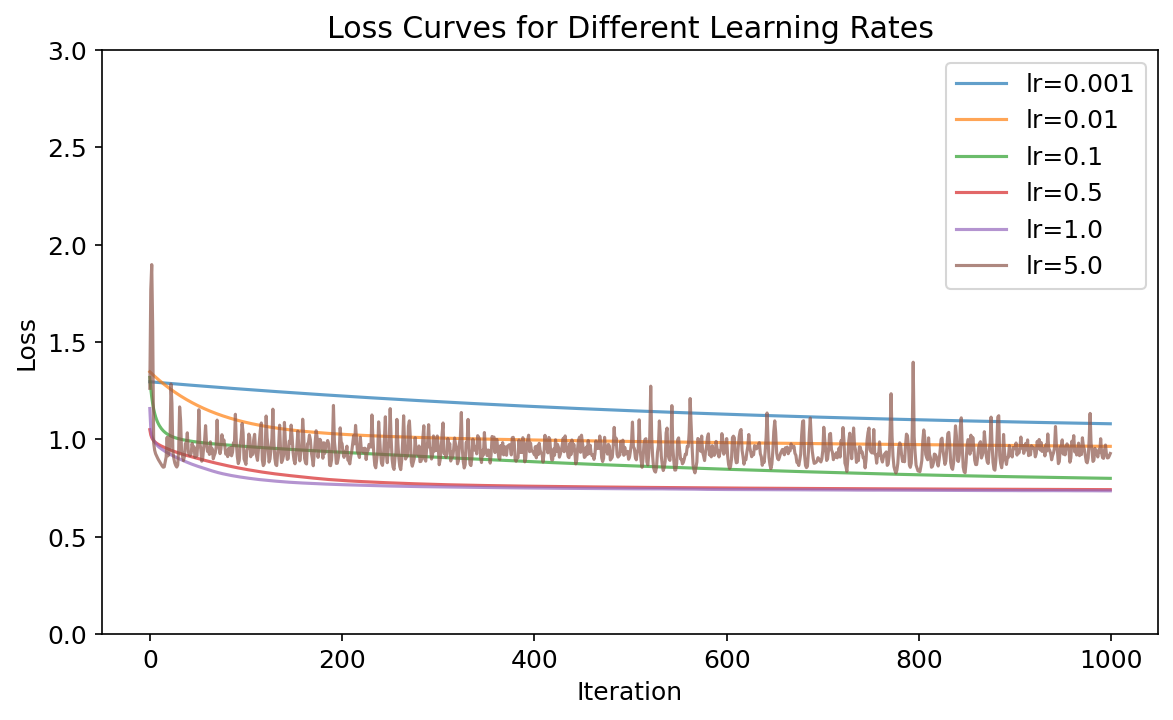

In [18]:
# Experiment: effect of learning rate
np.random.seed(42)
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
lr_results = []

for lr in learning_rates:
    net = TwoLayerNet(input_dim=2, hidden_dim=50, num_classes=3, reg=1e-3)
    losses = net.train(X_spiral, y_spiral, lr=lr, num_iters=1000)
    acc = np.mean(net.predict(X_spiral) == y_spiral)
    lr_results.append((lr, acc, losses))
    print(f"lr={lr:.3f}: accuracy={acc:.2%}, final_loss={losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for lr, _, losses in lr_results:
    ax.plot(losses, alpha=0.7, label=f'lr={lr}', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves for Different Learning Rates')
ax.legend()
ax.set_ylim(0, 3)
plt.tight_layout()
plt.savefig('learning_rate_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 5: Learning rate comparison")

### 6.3 正则化的影响

L2 正则化通过惩罚大权重来防止过拟合：
$$L_{total} = L_{data} + \lambda \|W\|^2$$

- $\lambda = 0$：无正则化，可能过拟合
- $\lambda$ 适中：防止过拟合
- $\lambda$ 太大：欠拟合（权重被压制到接近 0）

reg=0.0000: accuracy=72.33%, final_loss=0.6479
reg=0.0001: accuracy=73.33%, final_loss=0.6670
reg=0.0010: accuracy=72.00%, final_loss=0.7523
reg=0.0100: accuracy=59.33%, final_loss=0.9489
reg=0.1000: accuracy=48.00%, final_loss=1.0986
reg=1.0000: accuracy=33.33%, final_loss=1.0986
Experiment completed: regularization effect


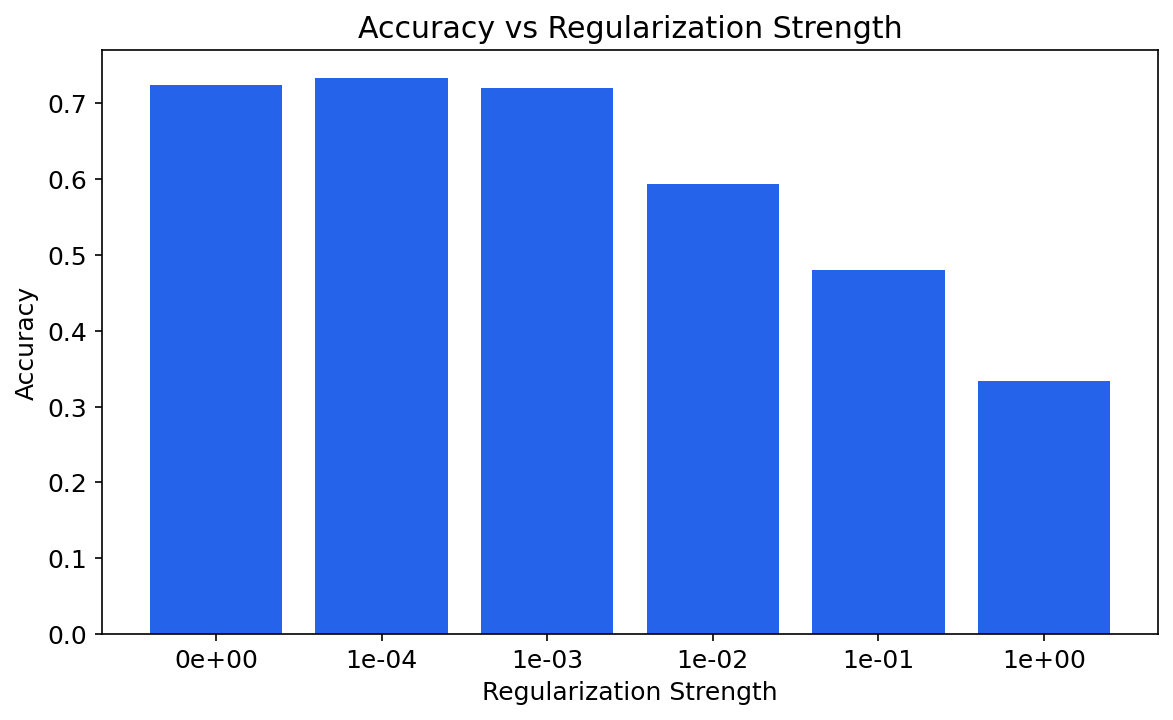

In [20]:
# Experiment: effect of regularization
np.random.seed(42)
reg_strengths = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
reg_results = []

for reg in reg_strengths:
    net = TwoLayerNet(input_dim=2, hidden_dim=100, num_classes=3, reg=reg)
    losses = net.train(X_spiral, y_spiral, lr=0.5, num_iters=1000)
    acc = np.mean(net.predict(X_spiral) == y_spiral)
    reg_results.append((reg, acc, losses[-1]))
    print(f"reg={reg:.4f}: accuracy={acc:.2%}, final_loss={losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
regs_str = [f'{r:.0e}' for r, _, _ in reg_results]
ax.bar(regs_str, [a for _, a, _ in reg_results], color='#2563eb')
ax.set_xlabel('Regularization Strength')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Regularization Strength')
plt.tight_layout()
plt.savefig('regularization_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Experiment completed: regularization effect")

## 7. 数值梯度检验

验证反向传播的正确性：用数值梯度（有限差分）与解析梯度比较。

$$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$$

相对误差应小于 $10^{-5}$。

In [22]:
# Numerical gradient checking
def numerical_grad(f, x, h=1e-5):
    """Compute numerical gradient using central difference."""
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = x[idx]
        x[idx] = old_val + h
        f_plus = f(x)
        x[idx] = old_val - h
        f_minus = f(x)
        x[idx] = old_val
        grad[idx] = (f_plus - f_minus) / (2 * h)
        it.iternext()
    return grad

np.random.seed(42)
# Small test
net = TwoLayerNet(input_dim=4, hidden_dim=10, num_classes=3, reg=0.1)
X_test = np.random.randn(5, 4)
y_test = np.array([0, 1, 2, 0, 1])

loss, grads = net.loss(X_test, y_test)

for name in ['W1', 'W2']:
    param = net.params[name]
    def loss_fn(p, name=name):
        net.params[name] = p
        l, _ = net.loss(X_test, y_test)
        return l
    
    num_grad = numerical_grad(loss_fn, param.copy())
    rel_error = np.max(np.abs(num_grad - grads[name]) / 
                       (np.maximum(1e-8, np.abs(num_grad) + np.abs(grads[name]))))
    print(f"{name}: max relative error = {rel_error:.2e}")
    assert rel_error < 1e-5, f"Gradient check failed for {name}!"
    
print("\nGradient check passed! Backward propagation is correct.")

W1: max relative error = 2.99e-09
W2: max relative error = 4.66e-10

Gradient check passed! Backward propagation is correct.


## 8. 完整训练流程可视化

将损失曲线和决策边界并排展示，观察训练过程中模型如何逐步学习非线性决策边界。

Visualization: Training progress snapshots


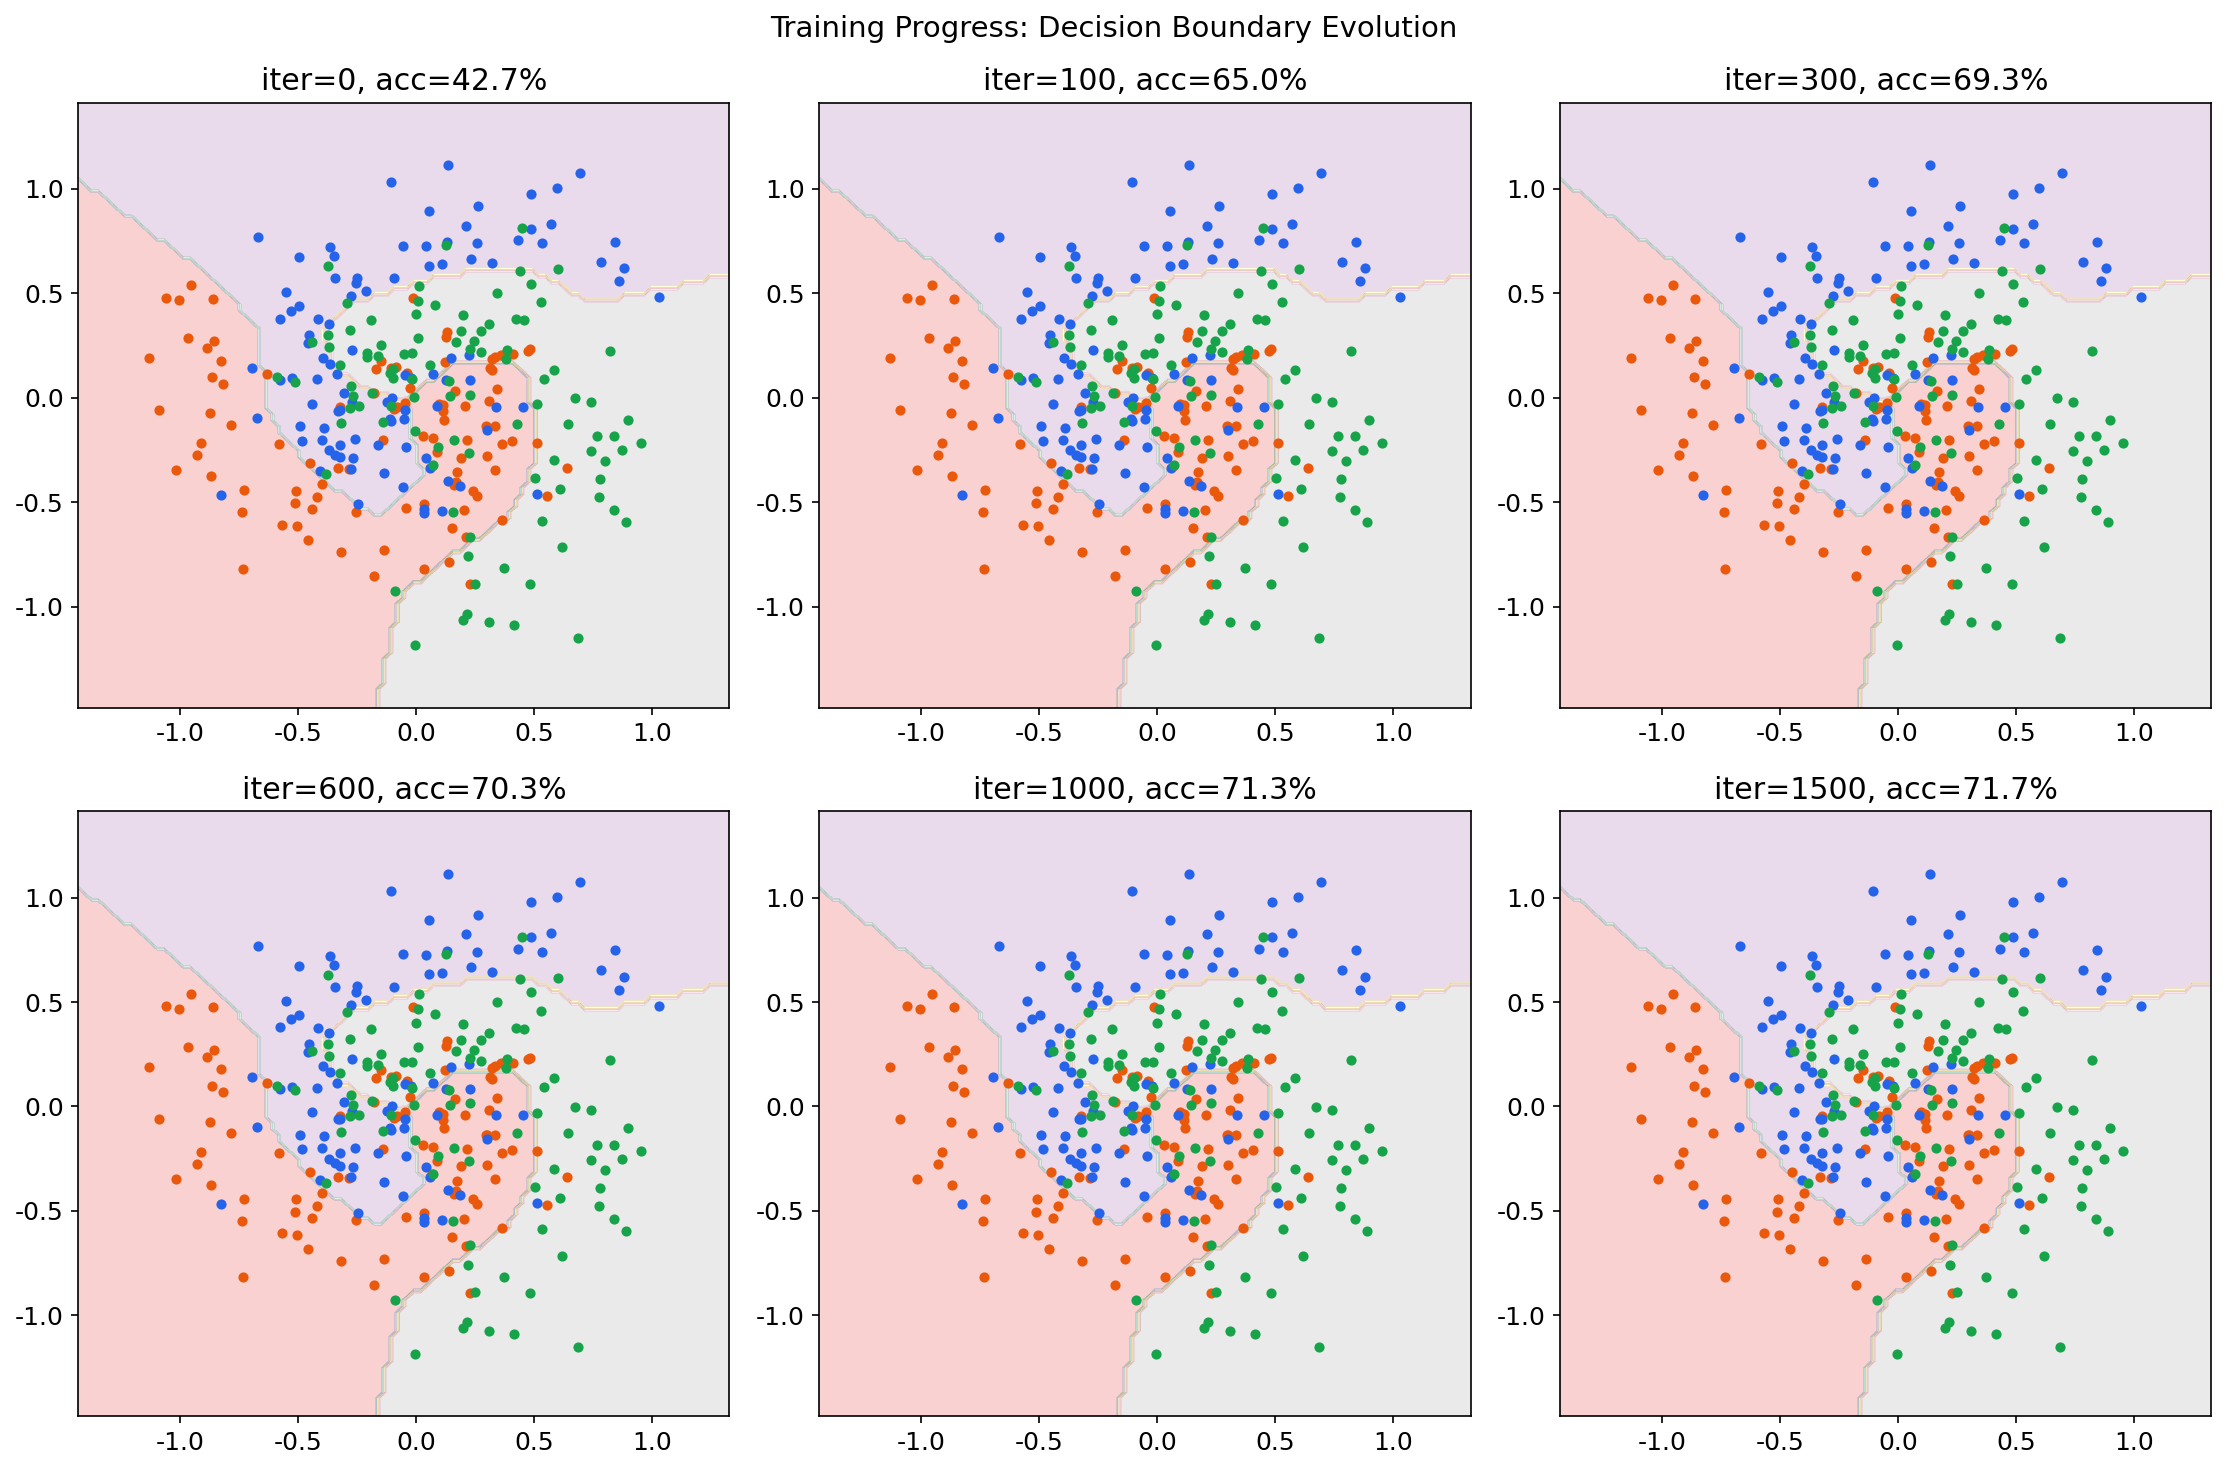

In [24]:
# Full training pipeline with periodic snapshots
np.random.seed(42)
net = TwoLayerNet(input_dim=2, hidden_dim=50, num_classes=3, reg=1e-3)

snapshots = [0, 100, 300, 600, 1000, 1500]
snapshot_models = []
all_losses = []

for it in range(1501):
    loss, grads = net.loss(X_spiral, y_spiral)
    for k in net.params:
        net.params[k] -= 0.5 * grads[k]
    all_losses.append(loss)
    if it in snapshots:
        # Save a copy of predictions
        snapshot_models.append((it, net.predict(X_spiral).copy(), 
                               net.forward(X_spiral)[0].copy()))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (it, preds, scores) in zip(axes.flat, snapshot_models):
    acc = np.mean(preds == y_spiral)
    x_min, x_max = X_spiral[:, 0].min() - 0.3, X_spiral[:, 0].max() + 0.3
    y_min, y_max = X_spiral[:, 1].min() - 0.3, X_spiral[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Recreate forward pass for grid
    z1 = grid @ net.params['W1'] + net.params['b1']
    a1 = np.maximum(0, z1)
    s = a1 @ net.params['W2'] + net.params['b2']
    Z = np.argmax(s, axis=1).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='Set1')
    for c in range(3):
        mask = y_spiral == c
        ax.scatter(X_spiral[mask, 0], X_spiral[mask, 1], c=colors[c], s=15)
    ax.set_title(f'iter={it}, acc={acc:.1%}')
plt.suptitle('Training Progress: Decision Boundary Evolution', fontsize=14)
plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization: Training progress snapshots")

## 作业

### 作业 1：实现三层神经网络

在 TwoLayerNet 的基础上，扩展为三层网络（两个隐藏层）：
$$f(x) = W_3 \cdot \text{ReLU}(W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2) + b_3$$

**要求**：实现前向传播和反向传播。

In [26]:
# Homework 1: Three-layer neural network
class ThreeLayerNet:
    def __init__(self, input_dim, hidden1, hidden2, num_classes, reg=0.0):
        self.params = {
            'W1': np.random.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim),
            'b1': np.zeros(hidden1),
            'W2': np.random.randn(hidden1, hidden2) * np.sqrt(2.0 / hidden1),
            'b2': np.zeros(hidden2),
            'W3': np.random.randn(hidden2, num_classes) * np.sqrt(2.0 / hidden2),
            'b3': np.zeros(num_classes),
        }
        self.reg = reg
    
    def forward(self, X):
        """Forward pass: input -> FC -> ReLU -> FC -> ReLU -> FC -> scores"""
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        W3, b3 = self.params['W3'], self.params['b3']
        # TODO: implement forward pass
        # z1 = ...; a1 = ...; z2 = ...; a2 = ...; scores = ...
        # return scores, (X, W1, b1, z1, a1, W2, b2, z2, a2, W3, b3)
        pass
    
    def loss(self, X, y):
        # TODO: compute loss and gradients
        pass
    
    def predict(self, X):
        scores, _ = self.forward(X)
        return np.argmax(scores, axis=1)

# Test
np.random.seed(42)
net3 = ThreeLayerNet(2, 30, 20, 3, reg=1e-3)
# Uncomment after implementation:
# losses = net3.train(X_spiral, y_spiral, lr=0.5, num_iters=1000)
# acc = np.mean(net3.predict(X_spiral) == y_spiral)
# assert acc > 0.8, "Three-layer net should achieve >80% accuracy"
print("Homework 1 template ready. Implement forward and loss methods.")

Homework 1 template ready. Implement forward and loss methods.


### 作业 2：实现 Adam 优化器

将 SGD 替换为 Adam 优化器，比较训练效果。

[[Kingma & Ba, 2015]](https://arxiv.org/abs/1412.6980)

In [28]:
# Homework 2: Adam optimizer for TwoLayerNet
def train_with_adam(net, X, y, lr=1e-3, num_iters=1000, 
                     beta1=0.9, beta2=0.999, eps=1e-8):
    """Train network with Adam optimizer.
    
    m_t = beta1 * m_{t-1} + (1-beta1) * g_t
    v_t = beta2 * v_{t-1} + (1-beta2) * g_t^2
    m_hat = m_t / (1 - beta1^t)
    v_hat = v_t / (1 - beta2^t)
    param -= lr * m_hat / (sqrt(v_hat) + eps)
    """
    m = {k: np.zeros_like(v) for k, v in net.params.items()}
    v = {k: np.zeros_like(v) for k, v in net.params.items()}
    losses = []
    for t in range(1, num_iters + 1):
        loss, grads = net.loss(X, y)
        # TODO: implement Adam update
        pass
        losses.append(loss)
    return losses

# Test
np.random.seed(42)
net_adam = TwoLayerNet(2, 50, 3, reg=1e-3)
# Uncomment after implementation:
# losses_adam = train_with_adam(net_adam, X_spiral, y_spiral, lr=1e-2, num_iters=1000)
# acc_adam = np.mean(net_adam.predict(X_spiral) == y_spiral)
# assert acc_adam > 0.9, "Adam should achieve >90% accuracy"
print("Homework 2 template ready. Implement Adam update rule.")

Homework 2 template ready. Implement Adam update rule.


### 作业 3：实现 Dropout 正则化

在隐藏层加入 Dropout，验证其正则化效果。

[[Srivastava et al., 2014]](https://jmlr.org/papers/v15/srivastava14a.html)

In [30]:
# Homework 3: Dropout in TwoLayerNet
def forward_with_dropout(self, X, p_drop=0.5, training=True):
    """Forward pass with inverted dropout.
    
    During training: mask = (rand < p_keep) / p_keep
    During inference: no modification
    """
    W1, b1 = self.params['W1'], self.params['b1']
    W2, b2 = self.params['W2'], self.params['b2']
    
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)
    
    # TODO: Apply dropout to a1
    # if training: mask = ...; a1 = a1 * mask
    pass
    
    scores = a1 @ W2 + b2
    return scores

# Test
np.random.seed(42)
net_drop = TwoLayerNet(2, 50, 3, reg=1e-3)
# Verify dropout: output should be different each forward call
# s1, _ = net_drop.forward_with_dropout(X_spiral, p_drop=0.5, training=True)
# s2, _ = net_drop.forward_with_dropout(X_spiral, p_drop=0.5, training=True)
# assert not np.allclose(s1, s2), "Dropout should produce different outputs"
# Verify inference: output should be deterministic
# s3, _ = net_drop.forward_with_dropout(X_spiral, p_drop=0.5, training=False)
# s4, _ = net_drop.forward_with_dropout(X_spiral, p_drop=0.5, training=False)
# assert np.allclose(s3, s4), "Inference should be deterministic"
print("Homework 3 template ready. Implement dropout forward pass.")

Homework 3 template ready. Implement dropout forward pass.


## 小结

| 概念 | 要点 |
|------|------|
| **参数化模型** | 用参数 W, b 压缩数据模式，预测只需矩阵乘法 |
| **前向传播** | $f(x) = W_2 \text{ReLU}(W_1 x + b_1) + b_2$ |
| **反向传播** | 链式法则沿计算图反向传递梯度 |
| **ReLU** | $\max(0, z)$，解决梯度消失，梯度为 0 或 1 |
| **Softmax** | 将得分转为概率分布，配合交叉熵损失 |
| **SGD** | $W \leftarrow W - \eta \nabla L$ |
| **He 初始化** | $W \sim N(0, \sqrt{2/D})$，适合 ReLU |
| **超参数** | 学习率最重要，隐藏层大小控制容量 |

**关键洞察**：两层网络能拟合任意非线性决策边界，但需要仔细调节超参数。学习率过大导致发散，过小导致收敛慢。正则化防止过拟合但太强会欠拟合。

## 参考文献

1. **CS231n Neural Networks Notes** - [cs231n.github.io/neural-networks-1](https://cs231n.github.io/neural-networks-1/)
2. **CS231n Optimization Notes** - [cs231n.github.io/optimization-2](https://cs231n.github.io/optimization-2/)
3. [[He et al., 2015]](https://arxiv.org/abs/1502.01852) He et al. *Delving Deep into Rectifiers*. He 初始化.
4. [[Glorot & Bengio, 2010]](https://proceedings.mlr.press/v9/glorot10a.html) Glorot & Bengio. *Understanding the difficulty of training deep feedforward neural networks*.
5. [[Kingma & Ba, 2015]](https://arxiv.org/abs/1412.6980) Kingma & Ba. *Adam: A Method for Stochastic Optimization*.
6. [[Srivastava et al., 2014]](https://jmlr.org/papers/v15/srivastava14a.html) Srivastava et al. *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*.

---

> 本节内容参考 [Stanford CS231n Assignment 1](https://cs231n.github.io/assignments2021/assignment1/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): CS231n 完整作业解答（KNN、SVM、Softmax、两层网络）
  - 仓库地址: https://github.com/jariasf/CS231n

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): 2019版 CS231n 作业 PyTorch+TensorFlow 解答
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 2020春季 CS231n 完整作业解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.